In [113]:
import numpy as np
import matplotlib.pyplot as plt

In [114]:
points = np.array([[1, 5], [3, 8], [7, 6], [9, 10]])
x = points[:, 0]
y = points[:, 1]

In [115]:
def cubic_spline_interpolation(x, y, s0=0, sn=0):
    n = len(x)
    num_segments = n - 1

    # --- Step 1: interval widths ---
    h = np.zeros(num_segments)
    for i in range(num_segments):
        h[i] = x[i+1] - x[i]

    # --- Step 2: Build tridiagonal system for c[1..n-2] ---
    # c[0] = c[n-1] = 0  (natural spline)
    size = n - 2   # number of unknowns: c1, c2, ..., c_{n-2}

    A   = np.zeros((size, size))
    rhs = np.zeros(size)

    for i in range(size):
        # i here corresponds to knot index (i+1) in the full array
        A[i, i] = 2 * (h[i] + h[i+1])
        if i > 0:
            A[i, i-1] = h[i]
        if i < size - 1:
            A[i, i+1] = h[i+1]

        rhs[i] = 3 * ((y[i+2] - y[i+1]) / h[i+1] - (y[i+1] - y[i]) / h[i])

    # --- Step 3: Solve ---
    c_inner = np.linalg.solve(A, rhs)

    # --- Step 4: Pad with boundary values ---
    c = np.zeros(n)
    c[0] = s0
    c[n-1] = sn
    c[1:n-1] = c_inner

    # --- Step 5: Back-calculate a, b, d ---
    a = np.zeros(num_segments)
    b = np.zeros(num_segments)
    d = np.zeros(num_segments)

    for i in range(num_segments):
        a[i] = y[i]
        d[i] = (c[i+1] - c[i]) / (3 * h[i])
        b[i] = (y[i+1] - y[i]) / h[i] - h[i] * (2*c[i] + c[i+1]) / 3

    return a, b, c[:-1], d

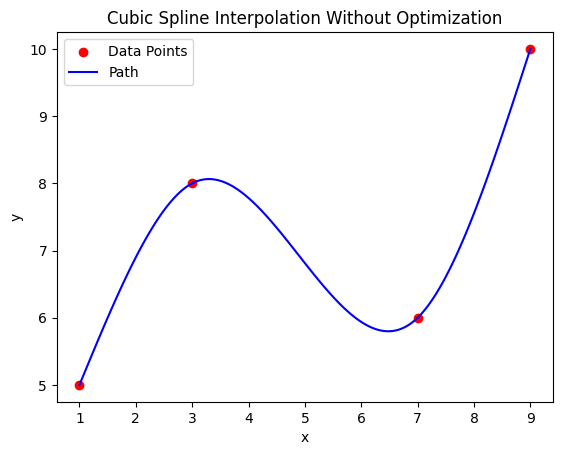

In [116]:
fig,axis = plt.subplots()
axis.scatter(x, y, color='red', label='Data Points')
a, b, c, d = cubic_spline_interpolation(x, y)
num_segments = len(a)
for i in range(num_segments):
    x_segment = np.linspace(x[i], x[i+1], 100)
    dx = x_segment - x[i]
    y_segment = a[i] + b[i]*dx + c[i]*dx**2 + d[i]*dx**3
    axis.plot(x_segment, y_segment, color='blue', label = "Path" if i == 0 else "")
axis.set_title('Cubic Spline Interpolation Without Optimization')
axis.set_xlabel('x')
axis.set_ylabel('y')
axis.legend()
plt.show()

In [117]:
def total_curvature(x,y,s0,sn,num_points = 500):
    a, b, c, d = cubic_spline_interpolation(x, y, s0, sn)
    num_segments = len(a)
    total_curvature = 0.0

    for i in range(num_segments):
        x_segment = np.linspace(x[i], x[i+1], num_points)
        dx = x_segment - x[i]
        y_segment = a[i] + b[i]*dx + c[i]*dx**2 + d[i]*dx**3

        # First derivative
        dy_dx = b[i] + 2*c[i]*dx + 3*d[i]*dx**2
        # Second derivative
        d2y_dx2 = 2*c[i] + 6*d[i]*dx

        curvature = np.abs(d2y_dx2) / (1 + dy_dx**2)**(3/2)
        total_curvature += np.trapezoid(curvature, x_segment)

    return total_curvature

In [118]:
def numerical_gradient(x, y, s0, sn, eps=1e-4):
    """Central difference gradient of total_curvature w.r.t. s0 and sn."""
    grad_s0 = (total_curvature(x, y, s0+eps, sn) -
               total_curvature(x, y, s0-eps, sn)) / (2*eps)
    grad_sn = (total_curvature(x, y, s0, sn+eps) -
               total_curvature(x, y, s0, sn-eps)) / (2*eps)
    return grad_s0, grad_sn

def gradient_descent(x, y, lr=0.01, n_iters=1000, eps=1e-4):
    """
    Minimize total curvature over (s0, sn) using gradient descent.
    Starts from natural spline: s0=0, sn=0.
    """
    s0, sn = 0.0, 0.0          # start from natural spline
    cost_history = []

    for iteration in range(n_iters):
        cost = total_curvature(x, y, s0, sn)
        cost_history.append(cost)

        grad_s0, grad_sn = numerical_gradient(x, y, s0, sn, eps)

        # update step
        s0 = s0 - lr * grad_s0
        sn = sn - lr * grad_sn

        if iteration % 50 == 0:
            print(f"iter {iteration:4d} | cost = {cost:.6f} | "
                  f"s0 = {s0:.4f} | sn = {sn:.4f} | "
                  f"grad = ({grad_s0:.4f}, {grad_sn:.4f})")

    return s0, sn, cost_history


In [119]:
s0_opt, sn_opt, cost_history = gradient_descent(x, y, lr=0.01, n_iters=1000)
print(f"Optimized s0: {s0_opt:.4f}, sn: {sn_opt:.4f}")
print(f"Natural spline curvature: {cost_history[0]:.6f}")
print(f"Optimized curvature: {cost_history[-1]:.6f}")

iter    0 | cost = 3.289957 | s0 = 0.0063 | sn = -0.0037 | grad = (-0.6272, 0.3735)
iter   50 | cost = 3.117680 | s0 = 0.2466 | sn = -0.1634 | grad = (-0.3619, 0.2730)
iter  100 | cost = 3.049748 | s0 = 0.3847 | sn = -0.2811 | grad = (-0.2085, 0.2026)
iter  150 | cost = 3.020920 | s0 = 0.4640 | sn = -0.3690 | grad = (-0.1189, 0.1526)
iter  200 | cost = 3.007720 | s0 = 0.5093 | sn = -0.4353 | grad = (-0.0676, 0.1153)
iter  250 | cost = 3.001227 | s0 = 0.5349 | sn = -0.4855 | grad = (-0.0381, 0.0877)
iter  300 | cost = 2.997843 | s0 = 0.5494 | sn = -0.5236 | grad = (-0.0216, 0.0665)
iter  350 | cost = 2.996006 | s0 = 0.5575 | sn = -0.5526 | grad = (-0.0119, 0.0507)
iter  400 | cost = 2.994984 | s0 = 0.5620 | sn = -0.5745 | grad = (-0.0066, 0.0383)
iter  450 | cost = 2.994406 | s0 = 0.5647 | sn = -0.5912 | grad = (-0.0042, 0.0287)
iter  500 | cost = 2.994080 | s0 = 0.5659 | sn = -0.6038 | grad = (-0.0019, 0.0220)
iter  550 | cost = 2.993894 | s0 = 0.5667 | sn = -0.6133 | grad = (-0.0012, 

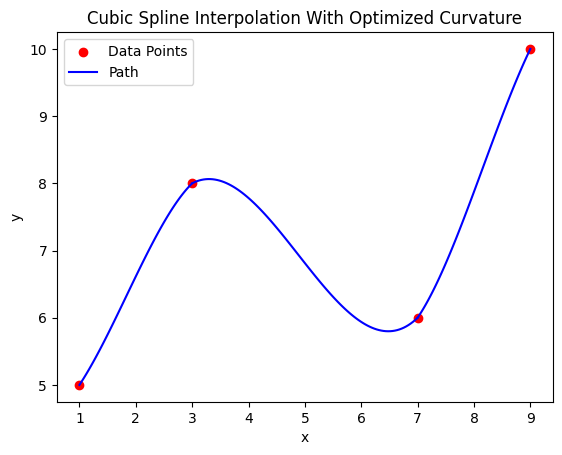

In [120]:
fig,axis = plt.subplots()
axis.scatter(x, y, color='red', label='Data Points')
a, b, c, d = cubic_spline_interpolation(x, y, s0_opt, sn_opt)
num_segments = len(a)
for i in range(num_segments):
    x_segment = np.linspace(x[i], x[i+1], 100)
    y_segment = a[i] + b[i]*(x_segment - x[i]) + c[i]*(x_segment - x[i])**2 + d[i]*(x_segment - x[i])**3
    axis.plot(x_segment, y_segment, color='blue', label = "Path" if i == 0 else "")
axis.set_title('Cubic Spline Interpolation With Optimized Curvature')
axis.set_xlabel('x')
axis.set_ylabel('y')
axis.legend()
plt.show()

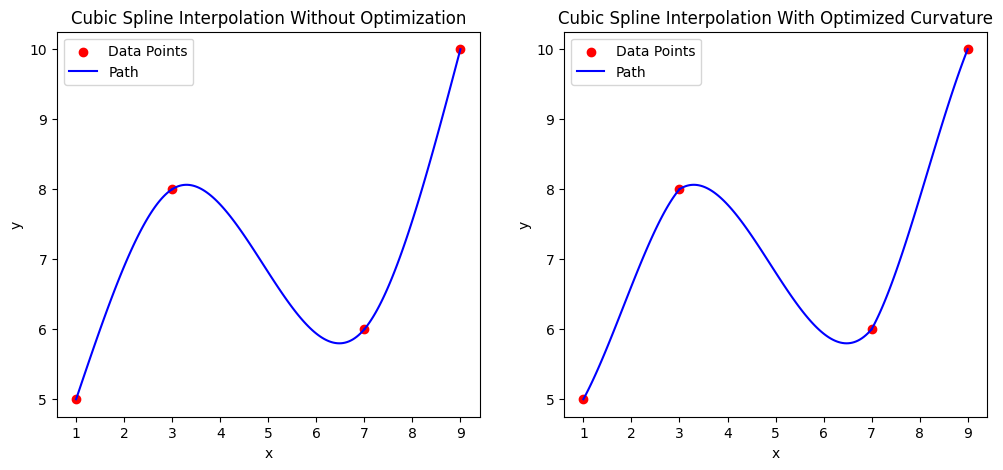

In [121]:
fig,axis = plt.subplots(1,2, figsize=(12,5))
axis[0].scatter(x, y, color='red', label='Data Points')
a, b, c, d = cubic_spline_interpolation(x, y)
num_segments = len(a)
for i in range(num_segments):
    x_segment = np.linspace(x[i], x[i+1], 100)
    dx = x_segment - x[i]
    y_segment = a[i] + b[i]*dx + c[i]*dx**2 + d[i]*dx**3
    axis[0].plot(x_segment, y_segment, color='blue', label = "Path" if i == 0 else "")
axis[0].set_title('Cubic Spline Interpolation Without Optimization')
axis[0].set_xlabel('x')
axis[0].set_ylabel('y')
axis[0].legend()

axis[1].scatter(x, y, color='red', label='Data Points')
a, b, c, d = cubic_spline_interpolation(x, y, s0_opt, sn_opt)
num_segments = len(a)
for i in range(num_segments):
    x_segment = np.linspace(x[i], x[i+1], 100)
    y_segment = a[i] + b[i]*(x_segment - x[i]) + c[i]*(x_segment - x[i])**2 + d[i]*(x_segment - x[i])**3
    axis[1].plot(x_segment, y_segment, color='blue', label = "Path" if i == 0 else "")
axis[1].set_title('Cubic Spline Interpolation With Optimized Curvature')
axis[1].set_xlabel('x')
axis[1].set_ylabel('y')
axis[1].legend()
plt.show()  